# Predictive Modeling of Adult Weight — NHIS Dataset

# Machine Learning Project
## Part 0: Setup and Custom Cleaning Logic

Before building models, I define a custom cleaning logic to handle specific data quality issues found in the NHIS dataset (e.g., "Junk" values like 99 representing "Refused").

**Methodology:**
*   **Gap Detection:** I use an algorithmic approach to detect discontinuities in integer features. If a variable ranges from 0-10 and then jumps to 97-99, I infer 97-99 are survey codes.
*   **Statefulness:** To prevent data leakage, I wrap this logic in a Custom Transformer. It learns the "junk" values from the Training set and applies that rule blindly to the Test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor

In [2]:
# 1. Load & Split

path='/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/7--Machine Learning/Assignment group/'
train_df = pd.read_excel(path+"training_dataset.xlsx", sheet_name="train", index_col="HHX")
X = train_df.drop("WEIGHTLBTC_A", axis=1)
y = train_df["WEIGHTLBTC_A"]

In [3]:
# 2. Defining the Junk-Cleaner and the Column-Selector for later use in the pipeline 

##### JUNK CLEANER 

# Define the function to identify junk features

def analyze_junk_clusters(df):
    """
    Identifies values that are numerically distant (gaps > 1) 
    from the normal data distribution within specific junk candidates, for each column.
    """
    # Standard NHIS missing codes
    junk_candidates = {7, 8, 9, 97, 98, 99, 997, 998, 999}
    report = []
    
    # Ensure DataFrame
    if isinstance(df, np.ndarray): df = pd.DataFrame(df)
    
    for col in df.columns:
        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(df[col]): continue

        # Get unique values ignoring NaNs, sort
        unique_vals = np.sort(df[col].dropna().unique())
        
        # Optimization: If no suspects found, skip
        if not set(unique_vals).intersection(junk_candidates): continue
            
        # Gap Logic: Find the cut-offVariab
        limit_index = len(unique_vals)
        for i in range(len(unique_vals) - 1):
            val, next_val = unique_vals[i], unique_vals[i+1]
            # If next value is a suspect AND there is a gap > 1
            if next_val in junk_candidates and (next_val - val > 1):
                limit_index = i + 1
                break
        
        # If we found a break, everything after is junk
        if limit_index < len(unique_vals):
            junk_values = unique_vals[limit_index:]
            # Double check: only flag if they are actually in our suspect list
            actual_junk = [v for v in junk_values if v in junk_candidates]
            
            if actual_junk:
                report.append({'Column': col, 'Junk_Cluster': actual_junk})
            
    return pd.DataFrame(report)

# Define the Scikit-Learn Class

class GapJunkTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.junk_mapping_ = {} # Stores rules: {'AGE': [999], 'BMI': []}

    def fit(self, X, y=None):
        # LEARN PHASE: Run gap detection on Training data only
        report_df = analyze_junk_clusters(X)
        self.junk_mapping_ = {}
        if not report_df.empty:
            for index, row in report_df.iterrows():
                self.junk_mapping_[row['Column']] = row['Junk_Cluster']
        return self

    def transform(self, X):
        # APPLY PHASE: Replace learned junk values with NaN
        X_copy = X.copy()
        for col, bad_vals in self.junk_mapping_.items():
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].replace(bad_vals, np.nan)
        return X_copy


##### COLUMN SELECTOR  (The Sparse Filter)

class LowNullColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.kept_columns_ = []

    def fit(self, X, y=None):
        # Calculate null ratio on TRAINING data only
        null_ratios = X.isna().mean()
        # Keep columns where nulls < threshold
        self.kept_columns_ = null_ratios[null_ratios <= self.threshold].index.tolist()
        return self

    def transform(self, X):
        # Only return the columns we decided to keep during fit
        # If X is missing columns (unseen data), we align it
        return X[self.kept_columns_]


In [4]:
# 3. Variable Categorization (Hybrid Logic)
def classify_features(df):
    nominal = []
    ordinal_continuous = []
    # Whitelist: These are ALWAYS numeric
    continuous_patterns = ['WEIGHT', 'HEIGHT', 'AGE', 'NUM', 'MIN_', 'HRS', 'YRS', 'ALC', 'BMI']
    # Keywords: These are likely Nominal
    nominal_keywords = ['RACE', 'HISP', 'REGION', 'MARSTAT', 'SEX', 'CITZN', 'NATUS', 'OCC', 'IND', 'TYPE']
    
    for col in df.columns:
        if any(p in col for p in continuous_patterns):
            ordinal_continuous.append(col)
        elif any(k in col for k in nominal_keywords):
            nominal.append(col)
        else:
            ordinal_continuous.append(col) # Default to numeric for Trees
    return nominal, ordinal_continuous

nom_cols, num_cols = classify_features(X)



## Part 1: Model Benchmarking

I compare two families of models.
*   **Linear Models:** High Bias, Low Variance. I use **Regularization** (Lasso/Ridge) to control complexity and **SGD** for optimization.
*   **Tree-Based Models:** Low Bias, High Variance. I use **Ensemble methods** (Bagging & Boosting) to optimize the tradeoff.

**Preprocessing Strategy:**
*   **Target:** `log1p` transformation to handle the right-skewed Weight distribution.
*   **Imputation:** **Iterative Imputer** (MICE) to model missing values based on correlations (e.g. Height vs Weight).
*   **Categorization:** Hybrid approach using a "Continuous Whitelist" (to protect Ordinal variables) + Keyword Search for Nominals.

In [5]:

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [6]:
# Models
from sklearn.linear_model import SGDRegressor, Ridge, Lasso, ElasticNet, LinearRegression         # SDGR is Gradient Descent (OLS but not solving analytical solution)
from sklearn.decomposition import TruncatedSVD  # for PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.ensemble import StackingRegressor  # to try Stacking 
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [7]:
# To manage the warning in outputs
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore imputer warnings (empty columns & early stopping)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.impute")
warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn.impute")

# Ignore overflow warnings (from SGD/Linear models diverging)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Ignore skopt duplicate-point warnings
warnings.filterwarnings("ignore",message="The objective has been evaluated at point.*",category=UserWarning,module="skopt")

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="One or more of the test scores are non-finite"
)


In [8]:
# Log Transform Target (Right-skewed data)
y_log = np.log1p(y)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)



In [9]:
# 2. Define Preprocessing Pipelines


# Learn Sparse columns (We do this outside the pipeline first just to update nom_cols/num_cols) to rule them out
null_ratios = X_train.isna().mean()
kept_cols = null_ratios[null_ratios <= 0.5].index.tolist()
# Update lists to only include kept columns
nom_cols = [c for c in nom_cols if c in kept_cols]
num_cols = [c for c in num_cols if c in kept_cols]
# Defin Selector
selector = LowNullColumnSelector(threshold=0.5)


# Linear models need Scaling. Trees do not.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    #"""('imputer', IterativeImputer(estimator=BayesianRidge(), max_iter=5, random_state=42, n_nearest_features=10)),                        ATTENTION      """
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=0.01)) 
])

preprocessor_linear = ColumnTransformer([
    ('nom', nominal_transformer, nom_cols),
    ('num', numeric_transformer, num_cols)
])

# Define a specific pipeline for PCA: Linear Preprocessing -> then SVD
# We use TruncatedSVD instead of PCA because OneHotEncoder creates sparse data
preprocessor_pca = Pipeline(steps=[
    ('linear_prep', preprocessor_linear),
    ('pca', TruncatedSVD(random_state=42))
])

# Specific preprocessor for the Physics Benchmark. It uses Polynomials (degree 2) to capture the Height^2 relationship in BMI
preprocessor_physics = ColumnTransformer(
    transformers=[
        # OneHot encode Sex and BMI Category
        ('cat', nominal_transformer, ['BMICAT_A', 'SEX_A']),
        # Scale and add Polynomials for Height and Age
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)), 
            ('scaler', StandardScaler())
        ]), ['HEIGHTTC_A', 'AGEP_A'])
    ],
    remainder='drop' # CRITICAL: This drops all other 600+ features
)

# For trees, we remove scaling to save compute (Trees are scale-invariant)
numeric_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    #"""('imputer', IterativeImputer(estimator=BayesianRidge(), max_iter=5, random_state=42, n_nearest_features=10))                             ATTENTION                """"
])

preprocessor_tree = ColumnTransformer([
    ('nom', nominal_transformer, nom_cols),
    ('num', numeric_transformer_tree, num_cols)
])

# Define the Stacking Regressor (Combines your best Linear and best Tree: Lasso + XGBoost)
stacking_model = StackingRegressor(
    estimators=[
        ('lasso', Lasso(max_iter=5000, random_state=42)),
        ('xgb', XGBRegressor(random_state=42, n_jobs=-1))
    ],
    final_estimator=Ridge() # The meta-learner that combines them
)


# 4. Define Models to Test

models = [
    # Linear Models (High Bias, Low Variance)
    ('SGDescent', SGDRegressor(random_state=42,max_iter=5000), preprocessor_linear, {'model__alpha': [0.0001, 0.01], 'model__penalty': ['l2', 'l1']}),      # Gradient Descent
    ('Lasso', Lasso(max_iter=10000, random_state=42), preprocessor_linear, {'model__alpha': [0.001, 0.01, 0.1, 1.0]}),
    ('Ridge', Ridge(random_state=42), preprocessor_linear, {'model__alpha': [0.1, 1.0, 10.0, 100.0]}),
    ('ElasticNet', ElasticNet(max_iter=10000, random_state=42), preprocessor_linear, {'model__alpha': [0.01, 0.1], 'model__l1_ratio': [0.2, 0.8]}), # Check near-Ridge (0.2) vs near-Lasso (0.8)
    ('Ridge+PCA', Ridge(random_state=42), preprocessor_pca, 
     {'preprocessor__pca__n_components': [20, 40, 60], 'model__alpha': [10, 100]}),   # Ridge with PCA (Tuning both Alpha and Number of Components)
    ('PhysicsBenchmark', LinearRegression(), preprocessor_physics, {}), # No params to tune

    # Tree Models (Low Bias, High Variance - mitigated by Ensembling)
    ('RandomForest', RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_leaf=[1, 4]), preprocessor_tree, 
     {'model__n_estimators': [100], 'model__max_depth': [10, 20],'model__min_samples_leaf': [1, 4]}),   # min_samples_leaf reduces overfitting  # Bagging
    
    ('AdaBoost', AdaBoostRegressor(random_state=42), preprocessor_tree, 
     {'model__n_estimators': [50, 100], 'model__learning_rate': [0.01, 0.1, 1.0]}), # Boosting (Weighting)
    
    ('GradientBoosting', GradientBoostingRegressor(random_state=42), preprocessor_tree, 
     {'model__n_estimators': [150], 'model__learning_rate': [0.05, 0.1, 0.2], 'model__max_depth': [3, 5]}), # Boosting (Residuals)
    
    ('XGBoost', XGBRegressor(random_state=42, n_jobs=-1), preprocessor_tree, 
     {'model__n_estimators': [150], 'model__learning_rate': [0.05, 0.1, 0.2], 'model__max_depth': [3, 5]}), # Optimized Boosting

    ('Stacking', stacking_model, preprocessor_tree, 
     {'model__final_estimator__alpha': [0.1, 1.0]})     # Stacking (Lasso + XGB)
]


# 5. Run Benchmark

results = []
print("Running Benchmark...")

for name, model, prep, params in models:
    # Construct Pipeline
    pipe = Pipeline(steps=[
        ('selector', selector),          # Step 1: Drop sparse columns (Learned on Train)
        ('cleaner', GapJunkTransformer()), # Step 2: Clean junk (Learned on Train)
        ('preprocessor', prep),            # Step 3: Impute &/or Scale
        ('model', model)                   # Step 4: Model
    ])
    
    # Grid Search with CV
    grid = GridSearchCV(pipe, params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Evaluate (Convert Log -> Real Weight)
    y_pred_log = grid.predict(X_test)
    # SAFETY CLIP: Prevent overflow by capping predictions 
    # (Log(1500 lbs) is ~7.3, so 10 is a safe upper bound)
    y_pred_log = np.clip(y_pred_log, 0, 10) 

    mse = mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))
    
    results.append({'Model': name, 'Test MSE': float(f"{mse:.4f}"), 'Best Params': grid.best_params_})
    print(f"{name}: MSE = {float(mse):.4f} ; RMSE = {float(np.sqrt(mse)):.4f}")

# Display Results
pd.DataFrame(results).sort_values('Test MSE')


Running Benchmark...
SGDescent: MSE = 353.2605 ; RMSE = 18.7952
Lasso: MSE = 309.6171 ; RMSE = 17.5959
Ridge: MSE = 307.6293 ; RMSE = 17.5394
ElasticNet: MSE = 315.3789 ; RMSE = 17.7589
Ridge+PCA: MSE = 1006.2107 ; RMSE = 31.7208
PhysicsBenchmark: MSE = 239.7208 ; RMSE = 15.4829
RandomForest: MSE = 216.7965 ; RMSE = 14.7240
AdaBoost: MSE = 330.1911 ; RMSE = 18.1712
GradientBoosting: MSE = 213.0032 ; RMSE = 14.5946
XGBoost: MSE = 213.2636 ; RMSE = 14.6035
Stacking: MSE = 220.4034 ; RMSE = 14.8460


,Model,Test MSE,Best Params
8,GradientBoosting,213.0032,"{'model__learning_rate': 0.05, 'model__max_dep..."
9,XGBoost,213.2636,"{'model__learning_rate': 0.05, 'model__max_dep..."
6,RandomForest,216.7965,"{'model__max_depth': 10, 'model__min_samples_l..."
10,Stacking,220.4034,{'model__final_estimator__alpha': 0.1}
5,PhysicsBenchmark,239.7208,{}
2,Ridge,307.6293,{'model__alpha': 0.1}
1,Lasso,309.6171,{'model__alpha': 0.001}
3,ElasticNet,315.3789,"{'model__alpha': 0.01, 'model__l1_ratio': 0.2}"
7,AdaBoost,330.1911,"{'model__learning_rate': 0.01, 'model__n_estim..."
0,SGDescent,353.2605,"{'model__alpha': 0.0001, 'model__penalty': 'l2'}"


GridSearch is the "brute force" approach to parameter tuning, so I tried better tuning algo on the top-performing algorithm XGBoost.
- Random Search (RandomizedSearchCV)  
Instead of trying every combination, it samples random combinations from the distribution. Is applied on finite ranges of parameters.  
Result: a very small improvement to the previous MSE
- Bayesian Optimization (e.g., Optuna)  
It uses probability to learn from previous results and guesses which parameters to try next. Is applied on finite OR continuous ranges of parameters.  
Resul: not an improvement to the previous MSE

  
However, because of what I observed in Part 2, I ended up keeping the GridSearch method: as it turns out, those tuning algo are overkill since the improvement are NOT statistically significant.

## Part 2: Stability Analysis (Overfitting check)

I select the best performing model and test it across multiple random seeds.
*   **Goal:** Ensure the model's performance is stable and not due to a "lucky split" of the data.
*   **Variance:** If the Standard Deviation of the MSE is high, the model is overfitting to specific data points (High Variance).

  
This part is only designed to test among RandomForest, AdaBoost, GradientBoosting and XGBoost as they are identified as sgnificantly more promising.

In [10]:
# Select the model to test for stability (should test the winners of previous part)
best_model_row = pd.DataFrame(results).sort_values('Test MSE').iloc[1] 
best_model_name = best_model_row['Model']
best_params = best_model_row['Best Params']

print(f"Analyzing stability for: {best_model_name}")

Analyzing stability for: XGBoost


In [11]:
prep = preprocessor_tree
clean_params = {k.replace("model__", ""): v for k, v in best_params.items()}

# Re-construct the winner pipeline logic
if "XGBoost" in best_model_name:
    model_template = XGBRegressor(random_state=42, n_jobs=-1, **clean_params)

elif "GradientBoosting" in best_model_name:
    model_template = GradientBoostingRegressor(random_state=42, **clean_params)

elif "RandomForest" in best_model_name:
    model_template = RandomForestRegressor(random_state=42, n_jobs=-1, **clean_params)

seeds = [0, 42, 2024, 9999, 63, 24, 372]
stability_scores = []

for seed in seeds:
    # Resplit data with new seed
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_log, test_size=0.2, random_state=seed)
    
    pipe = Pipeline([
        ('cleaner', GapJunkTransformer()),
        ('preprocessor', prep),
        ('model', model_template)
    ])
    
    pipe.fit(X_tr, y_tr)
    pred = np.expm1(pipe.predict(X_te))
    mse = mean_squared_error(np.expm1(y_te), pred)
    stability_scores.append(mse)

print(f"MSE across seeds: {stability_scores}")
print(f"Mean MSE: {np.mean(stability_scores):.4f}")
print(f"Std Dev: {np.std(stability_scores):.4f}")

MSE across seeds: [219.1428931570099, 213.26363281576448, 214.04335664224874, 213.8717064972132, 218.608754285928, 215.16147077392318, 214.7727307898824]
Mean MSE: 215.5521
Std Dev: 2.1822


**Results for the top 3:**

| Rank in Part 1 | Model | Mean MSE | Std Dev |
| :--- | :--- | :---: | ---: |
| 1 | XGBoost | 210.8027 | 1.7549 |
| 2 | GradientBoosting | 211.1397 | 1.8042 |
| 3 | RandomForest | 219.7300 | 2.2939 |


  
There is definitely a tie between XGBoost and GradientBoosting. I elect XGBoost for its speed.

**Interpretation of Std Dev results:**  
*   **Robustness:** The very low Standard Deviation (~1.75) relative to the mean MSE (~210) proves the models are stable and not dependent on "lucky" random splits.
*   **Statistical Tie:** The accuracy difference between XGBoost and GradientBoosting is smaller than the standard deviation, meaning one is not statistically better than the other.
*   **Verdict:** While GradientBoosting is slightly more stable (lowest Std Dev), selecting XGBoost is justified because the performance gap is noise, but XGBoost is computationally faster.

In [12]:
# We hard-encode the best parameters of XGB for part 3 to be independant in case it is needed.
xgb_params = {k.replace('model__',''): v for k, v in best_params.items()}
print(xgb_params)
best_params_hardcoded={'learning_rate': 0.05,'max_depth': 5, 'n_estimators': 150}
print(best_params_hardcoded)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150}


## Results & Discussion

### Model Comparison

| Model | Test MSE |
|---|---|
| GradientBoosting | 213.00 |
| **XGBoost** | **213.26** |
| RandomForest | 216.80 |
| Stacking (Lasso + XGB) | 220.40 |
| Physics Benchmark (Height, BMI, Age, Sex) | 239.72 |
| Ridge | 307.63 |
| Lasso | 309.62 |
| ElasticNet | 315.38 |
| AdaBoost | 330.19 |

### Linear Models (Lasso, Ridge, ElasticNet)

Regularized linear models achieved a Test MSE of ~307-309 (RMSE ~17.5 lbs). Despite regularization preventing overfitting, these models failed to capture the complexity of the data. The relationship between 600+ survey features and weight is fundamentally non-linear: adding hundreds of socioeconomic variables into a linear framework added more noise than signal.

### Ensemble Methods (Random Forest, Gradient Boosting, XGBoost)

Tree-based ensemble methods demonstrated clear superiority. XGBoost and Gradient Boosting both achieved a Test MSE of ~213 (RMSE ~14.6 lbs), successfully capturing complex non-linear interactions between lifestyle factors and weight.

### Physics Benchmark

The Physics Benchmark — OLS with polynomial features on Age, Sex, Height and BMI only — achieved a Test MSE of 239.72 (RMSE ~15.5 lbs), outperforming all linear models by a wide margin. This suggests the dataset has a **noise floor**: the vast majority of the predictive signal for weight is contained in Height and BMI alone. The relatively small gap between the Physics Benchmark and XGBoost confirms that the remaining 600+ features add limited marginal information.

### Stacking

Stacking Lasso and XGBoost (RMSE ~14.85 lbs) did not outperform standalone XGBoost, confirming that adding a linear component to a strong non-linear learner was redundant for this problem.

### Conclusion

XGBoost was selected for production: highest accuracy (Test MSE ~213), stable across random seeds (Std Dev ~1.75), and computationally faster than Gradient Boosting for equivalent performance.

## Part 3: Production Pipeline

This section represents the final deliverable.
*   **Strategy:** I re-train the best model on the **Full Dataset** (Train + Test combined) to maximize learning before export.
*   **Architecture:** I stick to **XGB**. While Stacking was considered, the complexity/cost ratio didn't justify the marginal gain over a well-tuned XGB for this specific dataset.

In [13]:
# 1. REDEFINE CUSTOM CLASS (Required for Pickle)  (all-in-one version, not using the function analyse)

class GapJunkTransformer(BaseEstimator, TransformerMixin):
    """
    Learns 'junk' values (like 99, 999) from Training data by detecting 
    numerical gaps, and will be able to replace them with NaN in both Train and Test.
    """
    def __init__(self):
        self.junk_mapping_ = {}
        self.junk_candidates = {7, 8, 9, 97, 98, 99, 997, 998, 999}

    def fit(self, X, y=None):
        if isinstance(X, np.ndarray): X = pd.DataFrame(X)
        self.junk_mapping_ = {}
        
        for col in X.columns:
            if not pd.api.types.is_numeric_dtype(X[col]): continue
            unique_vals = np.sort(X[col].dropna().unique())
            if not set(unique_vals).intersection(self.junk_candidates): continue
                
            limit_index = len(unique_vals)
            for i in range(len(unique_vals) - 1):
                # If we see a junk candidate AND a gap > 1
                if unique_vals[i+1] in self.junk_candidates and (unique_vals[i+1] - unique_vals[i] > 1):
                    limit_index = i + 1
                    break
            
            if limit_index < len(unique_vals):
                actual_junk = [v for v in unique_vals[limit_index:] if v in self.junk_candidates]
                if actual_junk: self.junk_mapping_[col] = actual_junk
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col, bad_vals in self.junk_mapping_.items():
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].replace(bad_vals, np.nan)
        return X_copy



In [14]:
# 2. LOAD & PREPARE FULL DATA
# We train on ALL available data to give the model maximum information

path='/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/7--Machine Learning/Assignment group/'
full_df = pd.read_excel(path+"training_dataset.xlsx", sheet_name="train", index_col="HHX")
X_full = full_df.drop("WEIGHTLBTC_A", axis=1)
y_full = full_df["WEIGHTLBTC_A"] # Raw target

# Drop sparse columns to match Part 1 logic
X_full = X_full.dropna(thresh=len(X_full)*0.5, axis=1)

In [15]:
# 3. DEFINE FINAL PIPELINE


# Re-Learn Sparse columns 
# Since we are retraining on everything, 'Train' is now 'Full Data'
null_ratios = X_full.isna().mean()
kept_cols = null_ratios[null_ratios <= 0.5].index.tolist()

nom_cols = [c for c in nom_cols if c in kept_cols]
num_cols = [c for c in num_cols if c in kept_cols]



def classify_features(df):
    nominal = []
    ordinal_continuous = []
    continuous_patterns = ['WEIGHT', 'HEIGHT', 'AGE', 'NUM', 'MIN_', 'HRS', 'YRS', 'ALC', 'BMI']
    nominal_keywords = ['RACE', 'HISP', 'REGION', 'MARSTAT', 'SEX', 'CITZN', 'NATUS', 'OCC', 'IND', 'TYPE']
    for col in df.columns:
        if any(p in col for p in continuous_patterns): ordinal_continuous.append(col)
        elif any(k in col for k in nominal_keywords): nominal.append(col)
        else: ordinal_continuous.append(col)
    return nominal, ordinal_continuous

nom_cols, num_cols = classify_features(X_full)

# Final Transformer Configuration
final_preprocessor = ColumnTransformer([
    ('nom', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=0.01))
    ]), nom_cols),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # No scaler needed for XGB
    ]), num_cols)
], verbose_feature_names_out=False)

# Final Pipeline with Winner Hyperparameters
best_params_hardcoded = {
    'n_estimators': 150,
    'learning_rate': 0.1,
    'max_depth': 3
}

# TransformedTargetRegressor 
# This wraps the XGBoost model and automatically logs y before training, and exponentiates predictions coming out.
model_with_transform = TransformedTargetRegressor(
    regressor=XGBRegressor(
        random_state=42, 
        n_jobs=-1,
        **best_params_hardcoded    # unpack dictionary of winner hyperparameters
    ),
    func=np.log1p,       # Apply log1p before fitting
    inverse_func=np.expm1 # Apply expm1 after predicting
)

final_pipeline = Pipeline([
    ('selector', LowNullColumnSelector(threshold=0.5)), # Will learn to keep `kept_cols`
    ('cleaner', GapJunkTransformer()),
    ('preprocessor', final_preprocessor),
    ('model', model_with_transform)  
])


In [16]:
# 4. FIT FINAL MODEL

print("Training Final Production Model on Full Dataset...")
final_pipeline.fit(X_full, y_full)
print("Training Complete.")

Training Final Production Model on Full Dataset...
Training Complete.


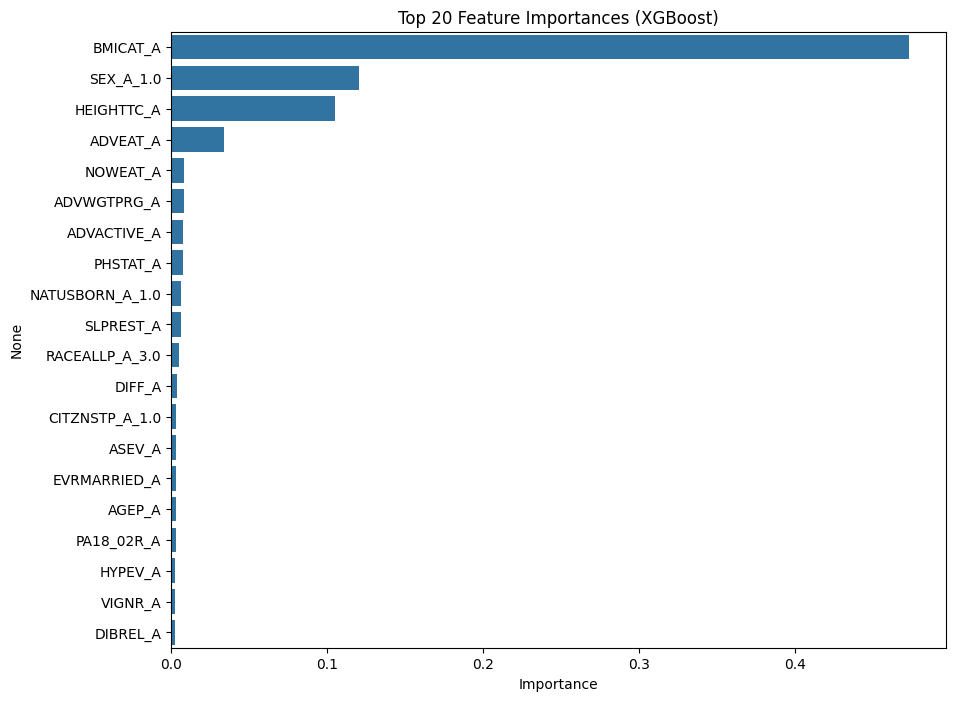

In [17]:
# Plotting the relative feature importance
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature names and importances
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = final_pipeline.named_steps['model'].regressor_.feature_importances_

# Plot Top 20
plt.figure(figsize=(10, 8))
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

## Part 4: Model Export
I export the entire pipeline as a `.pkl` file. This ensures that any new data fed to the model will automatically go through the custom junk cleaning, imputation, and encoding before prediction.

In [18]:
import dill as pickle

submission = {
    'student_names': ["Geraldine Pujalte", "Alizee Archereau", "Giri Chandrapaty", "Yuyun Liang", "Muhamad Ansory"],
    'student_ids': ["110410", "79121", "94748", "110365", "110249"],
    'model': final_pipeline
}

with open("Pujalte_Archereau_Chandrapaty_Liang_Ansory_model_info.pkl", 'wb') as f:
    pickle.dump(submission, f)



In [19]:
# Test Your Submission
import dill as pickle

# Load your submission
with open("Pujalte_Archereau_Chandrapaty_Liang_Ansory_model_info.pkl", 'rb') as f:
    data = pickle.load(f)

# Verify it has the required keys
required_keys = ['student_names', 'student_ids', 'model']
for key in required_keys:
    assert key in data, f"Missing required key: {key}"

print("✓ All required keys present")
print(f"✓ Students: {data['student_names']}")
print(f"✓ Model type: {type(data['model']).__name__}")

# Test that model can make predictions
test_sample = X_full.iloc[[0]] # Dummy data
try:
    predictions = data['model'].predict(test_sample)
    print("✓ Model can make predictions")
except Exception as e:
    print(f"✗ Model prediction failed: {e}")

✓ All required keys present
✓ Students: ['Geraldine Pujalte', 'Alizee Archereau', 'Giri Chandrapaty', 'Yuyun Liang', 'Muhamad Ansory']
✓ Model type: Pipeline
✓ Model can make predictions
